# Portfolio Optimization Under Uncertainty (CVaR)

## Problem Description

Classic mean-variance portfolio optimization (Markowitz) uses variance as a risk measure, but it penalizes upside and downside equally. **Conditional Value-at-Risk (CVaR)** is a coherent risk measure that focuses on tail losses.

### CVaR Optimization

$$\min_{w, \\alpha} \; \\alpha + \frac{1}{S(1-\\beta)} \sum_{s=1}^S \max\left(-r_s^T w - \\alpha, \; 0\right)$$

$$\text{s.t.} \quad \sum_i w_i = 1, \quad w_i \geq 0, \quad \mathbb{E}[r^T w] \geq \mu_{\text{target}}$$

Where:
- $w$ = portfolio weights
- $\\alpha$ = Value-at-Risk (VaR) at confidence level $\\beta$
- $r_s$ = return vector for scenario $s$
- $\\beta$ = confidence level (e.g., 0.95)

---

## Concepts
1. **Scenario-based optimization** — use historical/simulated returns
2. **CVaR as a linear program** — LP reformulation via auxiliary variables
3. **Efficient frontier** — mean-CVaR trade-off
4. **Comparison** with mean-variance (Markowitz)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pulp
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Portfolio Optimization with CVaR")
print("=" * 40)

Portfolio Optimization with CVaR


## 1. Generate Synthetic Asset Returns

In [3]:
# Simulate correlated asset returns (5 assets, 1000 scenarios)
n_assets = 5
n_scenarios = 1000
asset_names = ['Tech', 'Healthcare', 'Energy', 'Finance', 'Bonds']

# Expected annual returns and volatilities
expected_returns = np.array([0.12, 0.09, 0.08, 0.10, 0.03])
volatilities = np.array([0.25, 0.18, 0.22, 0.20, 0.05])

# Correlation matrix
corr = np.array([
    [1.0, 0.5, 0.3, 0.6, -0.1],
    [0.5, 1.0, 0.2, 0.4, 0.0],
    [0.3, 0.2, 1.0, 0.3, 0.1],
    [0.6, 0.4, 0.3, 1.0, -0.05],
    [-0.1, 0.0, 0.1, -0.05, 1.0]
])

# Covariance matrix
cov = np.outer(volatilities, volatilities) * corr

# Generate scenarios (multivariate normal)
rng = np.random.default_rng(42)
returns = rng.multivariate_normal(expected_returns, cov, n_scenarios)

print(f"Assets: {asset_names}")
print(f"\nExpected returns: {expected_returns}")
print(f"Volatilities: {volatilities}")
print(f"\nScenarios generated: {n_scenarios}")
print(f"\nSample statistics:")
print(f"  Mean returns: {returns.mean(axis=0).round(4)}")
print(f"  Std returns:  {returns.std(axis=0).round(4)}")

Assets: ['Tech', 'Healthcare', 'Energy', 'Finance', 'Bonds']

Expected returns: [0.12 0.09 0.08 0.1  0.03]
Volatilities: [0.25 0.18 0.22 0.2  0.05]

Scenarios generated: 1000

Sample statistics:
  Mean returns: [0.1286 0.0972 0.0838 0.1095 0.0279]
  Std returns:  [0.2444 0.1825 0.2307 0.198  0.0485]


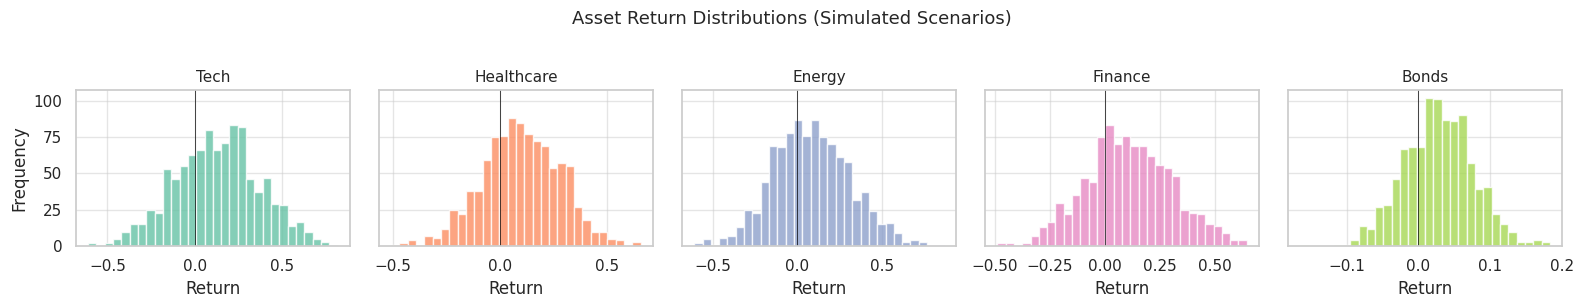

In [4]:
# Visualize return distributions
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
colors = sns.color_palette('Set2', n_assets)

for i, (ax, name) in enumerate(zip(axes, asset_names)):
    ax.hist(returns[:, i], bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Return')

axes[0].set_ylabel('Frequency')
plt.suptitle('Asset Return Distributions (Simulated Scenarios)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. CVaR Optimization via Linear Programming

The CVaR minimization can be reformulated as an LP by introducing auxiliary variables $z_s$:

$$\min_{w, \\alpha, z} \; \\alpha + \frac{1}{S(1-\\beta)} \sum_s z_s$$
$$\text{s.t.} \quad z_s \geq -r_s^T w - \\alpha, \; z_s \geq 0, \; \sum w_i = 1, \; w_i \geq 0$$

In [5]:
def optimize_cvar(returns, beta=0.95, target_return=None):
    """
    Minimize CVaR at confidence level beta.
    
    Parameters
    ----------
    returns : np.ndarray, shape (n_scenarios, n_assets)
    beta : float, confidence level (e.g., 0.95)
    target_return : float or None, minimum expected return constraint
    
    Returns
    -------
    dict with keys: 'weights', 'cvar', 'var', 'expected_return'
    """
    n_scen, n_assets = returns.shape
    
    prob = pulp.LpProblem("CVaR_Portfolio", pulp.LpMinimize)
    
    # Variables
    w = [pulp.LpVariable(f"w_{i}", lowBound=0) for i in range(n_assets)]
    alpha = pulp.LpVariable("alpha")  # VaR
    z = [pulp.LpVariable(f"z_{s}", lowBound=0) for s in range(n_scen)]
    
    # Objective: minimize CVaR
    prob += alpha + (1.0 / (n_scen * (1 - beta))) * pulp.lpSum(z)
    
    # Constraints
    for s in range(n_scen):
        prob += z[s] >= -pulp.lpSum(returns[s, i] * w[i] for i in range(n_assets)) - alpha
    
    # Budget constraint
    prob += pulp.lpSum(w) == 1
    
    # Target return constraint
    if target_return is not None:
        mean_returns = returns.mean(axis=0)
        prob += pulp.lpSum(mean_returns[i] * w[i] for i in range(n_assets)) >= target_return
    
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    
    w_val = np.array([pulp.value(w[i]) for i in range(n_assets)])
    alpha_val = pulp.value(alpha)
    cvar_val = pulp.value(prob.objective)
    exp_ret = np.dot(returns.mean(axis=0), w_val)
    
    return {
        'weights': w_val,
        'cvar': cvar_val,
        'var': -alpha_val,
        'expected_return': exp_ret,
    }

# Solve minimum CVaR portfolio
result = optimize_cvar(returns, beta=0.95)

print("MINIMUM CVaR PORTFOLIO (β = 95%)")
print("=" * 45)
print(f"CVaR (95%): {result['cvar']:.4f} ({result['cvar']*100:.2f}%)")
print(f"VaR (95%): {result['var']:.4f} ({result['var']*100:.2f}%)")
print(f"Expected return: {result['expected_return']:.4f} ({result['expected_return']*100:.2f}%)")
print(f"\nOptimal weights:")
for name, w in zip(asset_names, result['weights']):
    print(f"  {name:<12}: {w:.4f} ({w*100:.1f}%)")

MINIMUM CVaR PORTFOLIO (β = 95%)
CVaR (95%): 0.0558 (5.58%)
VaR (95%): -0.0354 (-3.54%)
Expected return: 0.0392 (3.92%)

Optimal weights:
  Tech        : 0.0119 (1.2%)
  Healthcare  : 0.0436 (4.4%)
  Energy      : 0.0107 (1.1%)
  Finance     : 0.0799 (8.0%)
  Bonds       : 0.8540 (85.4%)


## 3. Efficient Frontier (Mean-CVaR)

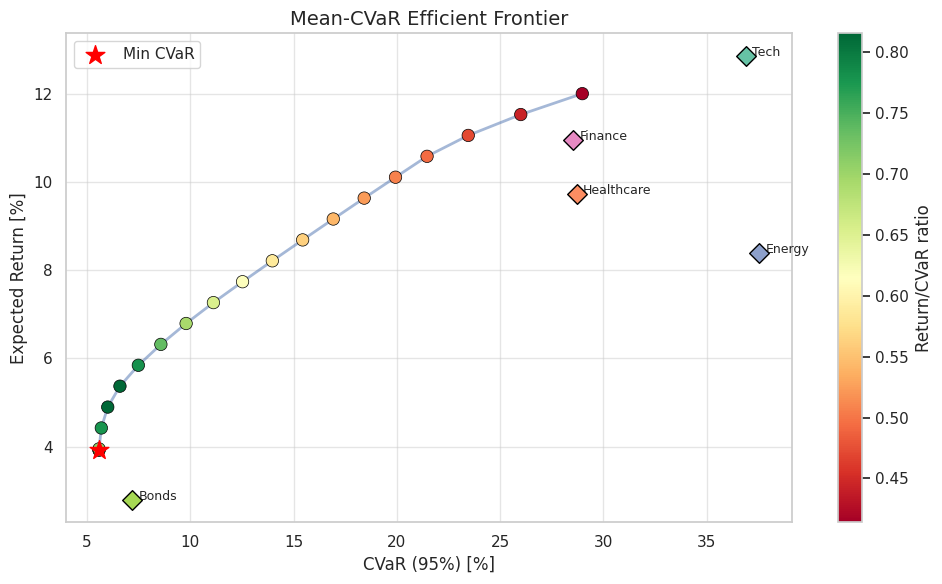

In [6]:
# Compute efficient frontier
target_returns = np.linspace(0.03, 0.12, 20)
frontier_cvar = []
frontier_returns = []
frontier_weights = []

for mu_target in target_returns:
    try:
        res = optimize_cvar(returns, beta=0.95, target_return=mu_target)
        if res['weights'] is not None and not np.any(np.isnan(res['weights'])):
            frontier_cvar.append(res['cvar'])
            frontier_returns.append(res['expected_return'])
            frontier_weights.append(res['weights'])
    except Exception:
        pass

frontier_cvar = np.array(frontier_cvar)
frontier_returns = np.array(frontier_returns)
frontier_weights = np.array(frontier_weights)

# Plot efficient frontier
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(frontier_cvar * 100, frontier_returns * 100, 
                     c=frontier_returns / (frontier_cvar + 1e-9), cmap='RdYlGn', 
                     s=80, edgecolors='black', linewidths=0.5, zorder=3)
ax.plot(frontier_cvar * 100, frontier_returns * 100, 'b-', alpha=0.5, linewidth=2)

# Mark minimum CVaR portfolio
ax.scatter([result['cvar'] * 100], [result['expected_return'] * 100],
           color='red', s=200, marker='*', zorder=5, label='Min CVaR')

# Mark individual assets
for i, name in enumerate(asset_names):
    asset_ret = returns.mean(axis=0)[i]
    asset_losses = -returns[:, i]
    var_95 = np.percentile(asset_losses, 95)
    cvar_95 = asset_losses[asset_losses >= var_95].mean()
    ax.scatter([cvar_95 * 100], [asset_ret * 100], marker='D', s=100, 
              color=colors[i], edgecolors='black', zorder=4)
    ax.annotate(name, (cvar_95 * 100 + 0.3, asset_ret * 100), fontsize=9)

plt.colorbar(scatter, label='Return/CVaR ratio')
ax.set_xlabel('CVaR (95%) [%]', fontsize=12)
ax.set_ylabel('Expected Return [%]', fontsize=12)
ax.set_title('Mean-CVaR Efficient Frontier', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Portfolio Composition Along the Frontier

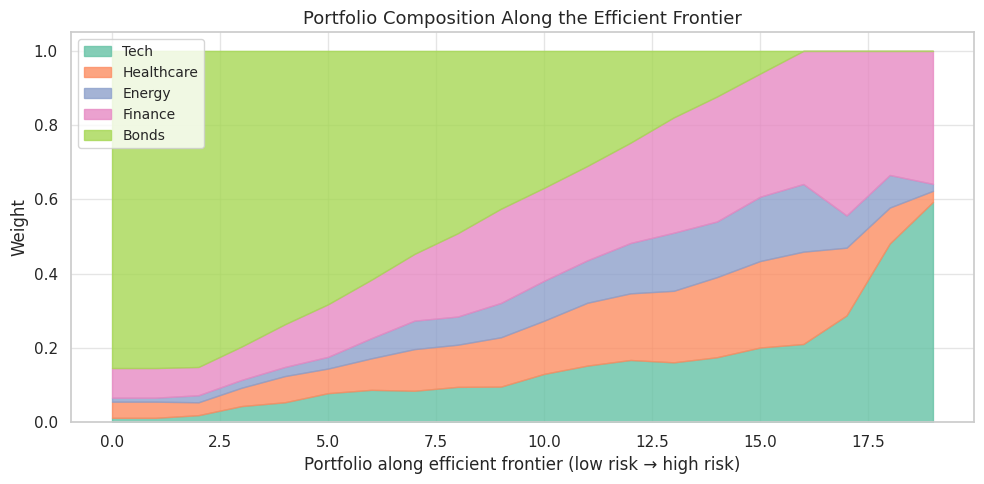

In [7]:
# Portfolio composition
fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(frontier_weights))
for i in range(n_assets):
    weights_i = frontier_weights[:, i]
    ax.fill_between(range(len(frontier_weights)), bottom, bottom + weights_i,
                    alpha=0.8, label=asset_names[i], color=colors[i])
    bottom += weights_i

ax.set_xlabel('Portfolio along efficient frontier (low risk → high risk)', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.set_title('Portfolio Composition Along the Efficient Frontier', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 5. Out-of-Sample Backtesting

Portfolio            Mean Ret   Std        CVaR 95%   Sharpe
Min CVaR             4.00      % 4.74      % 5.70      % 0.843
Equal Weight (1/N)   7.79      % 12.75     % 17.03     % 0.611
Max Return           10.61     % 20.94     % 28.25     % 0.507


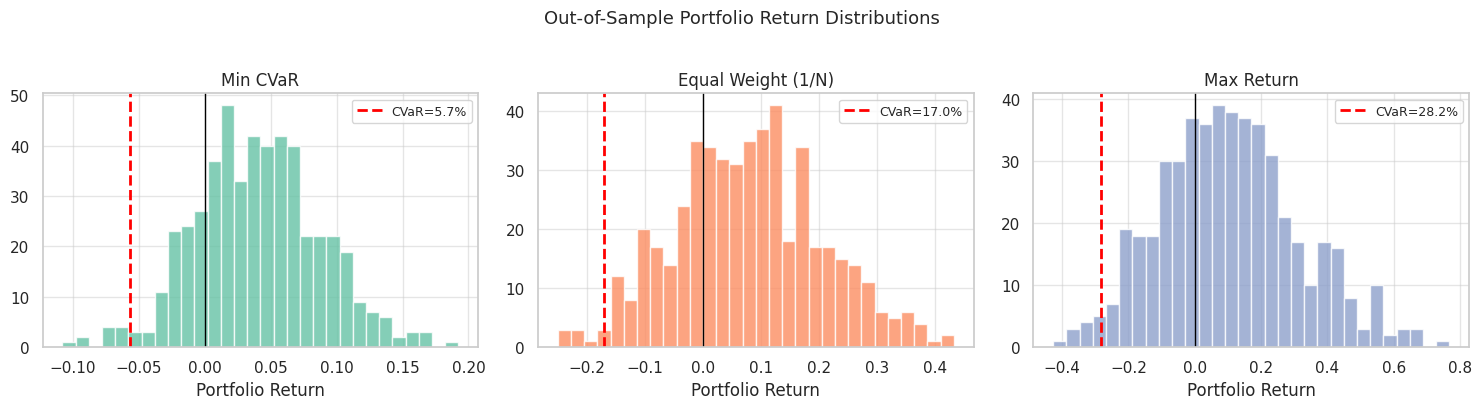

In [8]:
# Generate out-of-sample returns
oos_returns = rng.multivariate_normal(expected_returns, cov, 500)

# Compare portfolios
min_cvar_weights = result['weights']
equal_weights = np.ones(n_assets) / n_assets
max_ret_weights = frontier_weights[-1] if len(frontier_weights) > 0 else equal_weights

portfolios = {
    'Min CVaR': min_cvar_weights,
    'Equal Weight (1/N)': equal_weights,
    'Max Return': max_ret_weights,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

print(f"{'Portfolio':<20} {'Mean Ret':<10} {'Std':<10} {'CVaR 95%':<10} {'Sharpe'}")
print('=' * 60)

for idx, (name, weights) in enumerate(portfolios.items()):
    port_returns = oos_returns @ weights
    mean_r = port_returns.mean()
    std_r = port_returns.std()
    losses = -port_returns
    var_95 = np.percentile(losses, 95)
    cvar_95 = losses[losses >= var_95].mean()
    sharpe = mean_r / std_r if std_r > 0 else 0
    
    print(f"{name:<20} {mean_r*100:<10.2f}% {std_r*100:<10.2f}% {cvar_95*100:<10.2f}% {sharpe:.3f}")
    
    axes[idx].hist(port_returns, bins=30, color=colors[idx], edgecolor='white', alpha=0.8)
    axes[idx].axvline(0, color='black', linewidth=1)
    axes[idx].axvline(-cvar_95, color='red', linestyle='--', linewidth=2, label=f'CVaR={cvar_95*100:.1f}%')
    axes[idx].set_title(name, fontsize=12)
    axes[idx].set_xlabel('Portfolio Return')
    axes[idx].legend(fontsize=9)

plt.suptitle('Out-of-Sample Portfolio Return Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Approach | Pros | Cons |
|----------|------|------|
| Mean-Variance | Closed-form, fast | Symmetric risk, Gaussian assumption |
| Mean-CVaR | Focuses on tail risk, LP formulation | Requires scenarios |
| Scenario-based | Flexible distributions | Sample-dependent |

### Notes
- **CVaR** is a coherent risk measure — it satisfies subadditivity (diversification always helps)
- The CVaR problem is a **Linear Program** — scalable to many assets and scenarios
- The efficient frontier reveals the **risk-return trade-off** under tail risk
- Conservative portfolios are heavy on bonds; aggressive ones concentrate in high-return equities
- Out-of-sample validation is essential to check for overfitting to scenarios